# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fakhrul Ghozali Akbar S
- Email: barz.develop@gmail.com
- Id Dicoding: fakhrul_akbar

## Persiapan

### Menyiapkan library yang dibutuhkan

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN

### Menyiapkan data yang akan diguankan

## Data Understanding

In [10]:
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**💡 Insight:** Dataset ini memiliki beberapa kelompok kolom sebagai berikut:

- **👤 Data Pribadi & Demografis:**<br>
  Marital_status, Gender, Age_at_enrollment, Nacionality, International  

- **🎓 Data Pendaftaran & Pendidikan:**<br>
  Application_mode, Application_order, Course, Daytime_evening_attendance,<br>
  Previous_qualification, Previous_qualification_grade, Admission_grade  

- **👨‍👩‍👧 Latar Belakang Keluarga:**<br>
  Mothers_qualification, Fathers_qualification, Mothers_occupation, Fathers_occupation  

- **💰 Sosial & Ekonomi Individu:**<br>
  Displaced, Educational_special_needs, Debtor, Tuition_fees_up_to_date, Scholarship_holder  

- **📚 Aktivitas Akademik Semester 1:**<br>
  Curricular_units_1st_sem_credited, Curricular_units_1st_sem_enrolled,<br>
  Curricular_units_1st_sem_evaluations, Curricular_units_1st_sem_approved,<br>
  Curricular_units_1st_sem_grade, Curricular_units_1st_sem_without_evaluations  

- **📚 Aktivitas Akademik Semester 2:**<br>
  Curricular_units_2nd_sem_credited, Curricular_units_2nd_sem_enrolled,<br>
  Curricular_units_2nd_sem_evaluations, Curricular_units_2nd_sem_approved,<br>
  Curricular_units_2nd_sem_grade, Curricular_units_2nd_sem_without_evaluations  

- **🌍 Faktor Ekonomi Makro:**<br>
  Unemployment_rate, Inflation_rate, GDP  

- **🎯 Target:** Status

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

**💡 Insight:** Terdapat 4424 data dengan 35 kolom numerik dan 1 kolom kategorikal sebagai target. 

In [5]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


**💡 Insight:** tidak ada missing value pada data

In [6]:
duplicated = df.duplicated().sum()
print(f'duplicated data : {duplicated}')

duplicated data : 0


**💡 Insight:** tidak ada duplikat data 

In [12]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [15]:
df.describe(include='object')

,Status
count,4424
unique,3
top,Graduate
freq,2209


In [28]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

**💡 Insight:** Secara umum, dataset dalam kondisi baik, bersih, dan tidak menunjukkan anomali besar, sehingga siap digunakan untuk analisis lanjutan maupun modeling.

Mayoritas data target / status terdapat pada nilai "Graduate"

## Data Preparation / Preprocessing

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])

In [19]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Text(0.5, 1.0, 'Correlation Matrix')

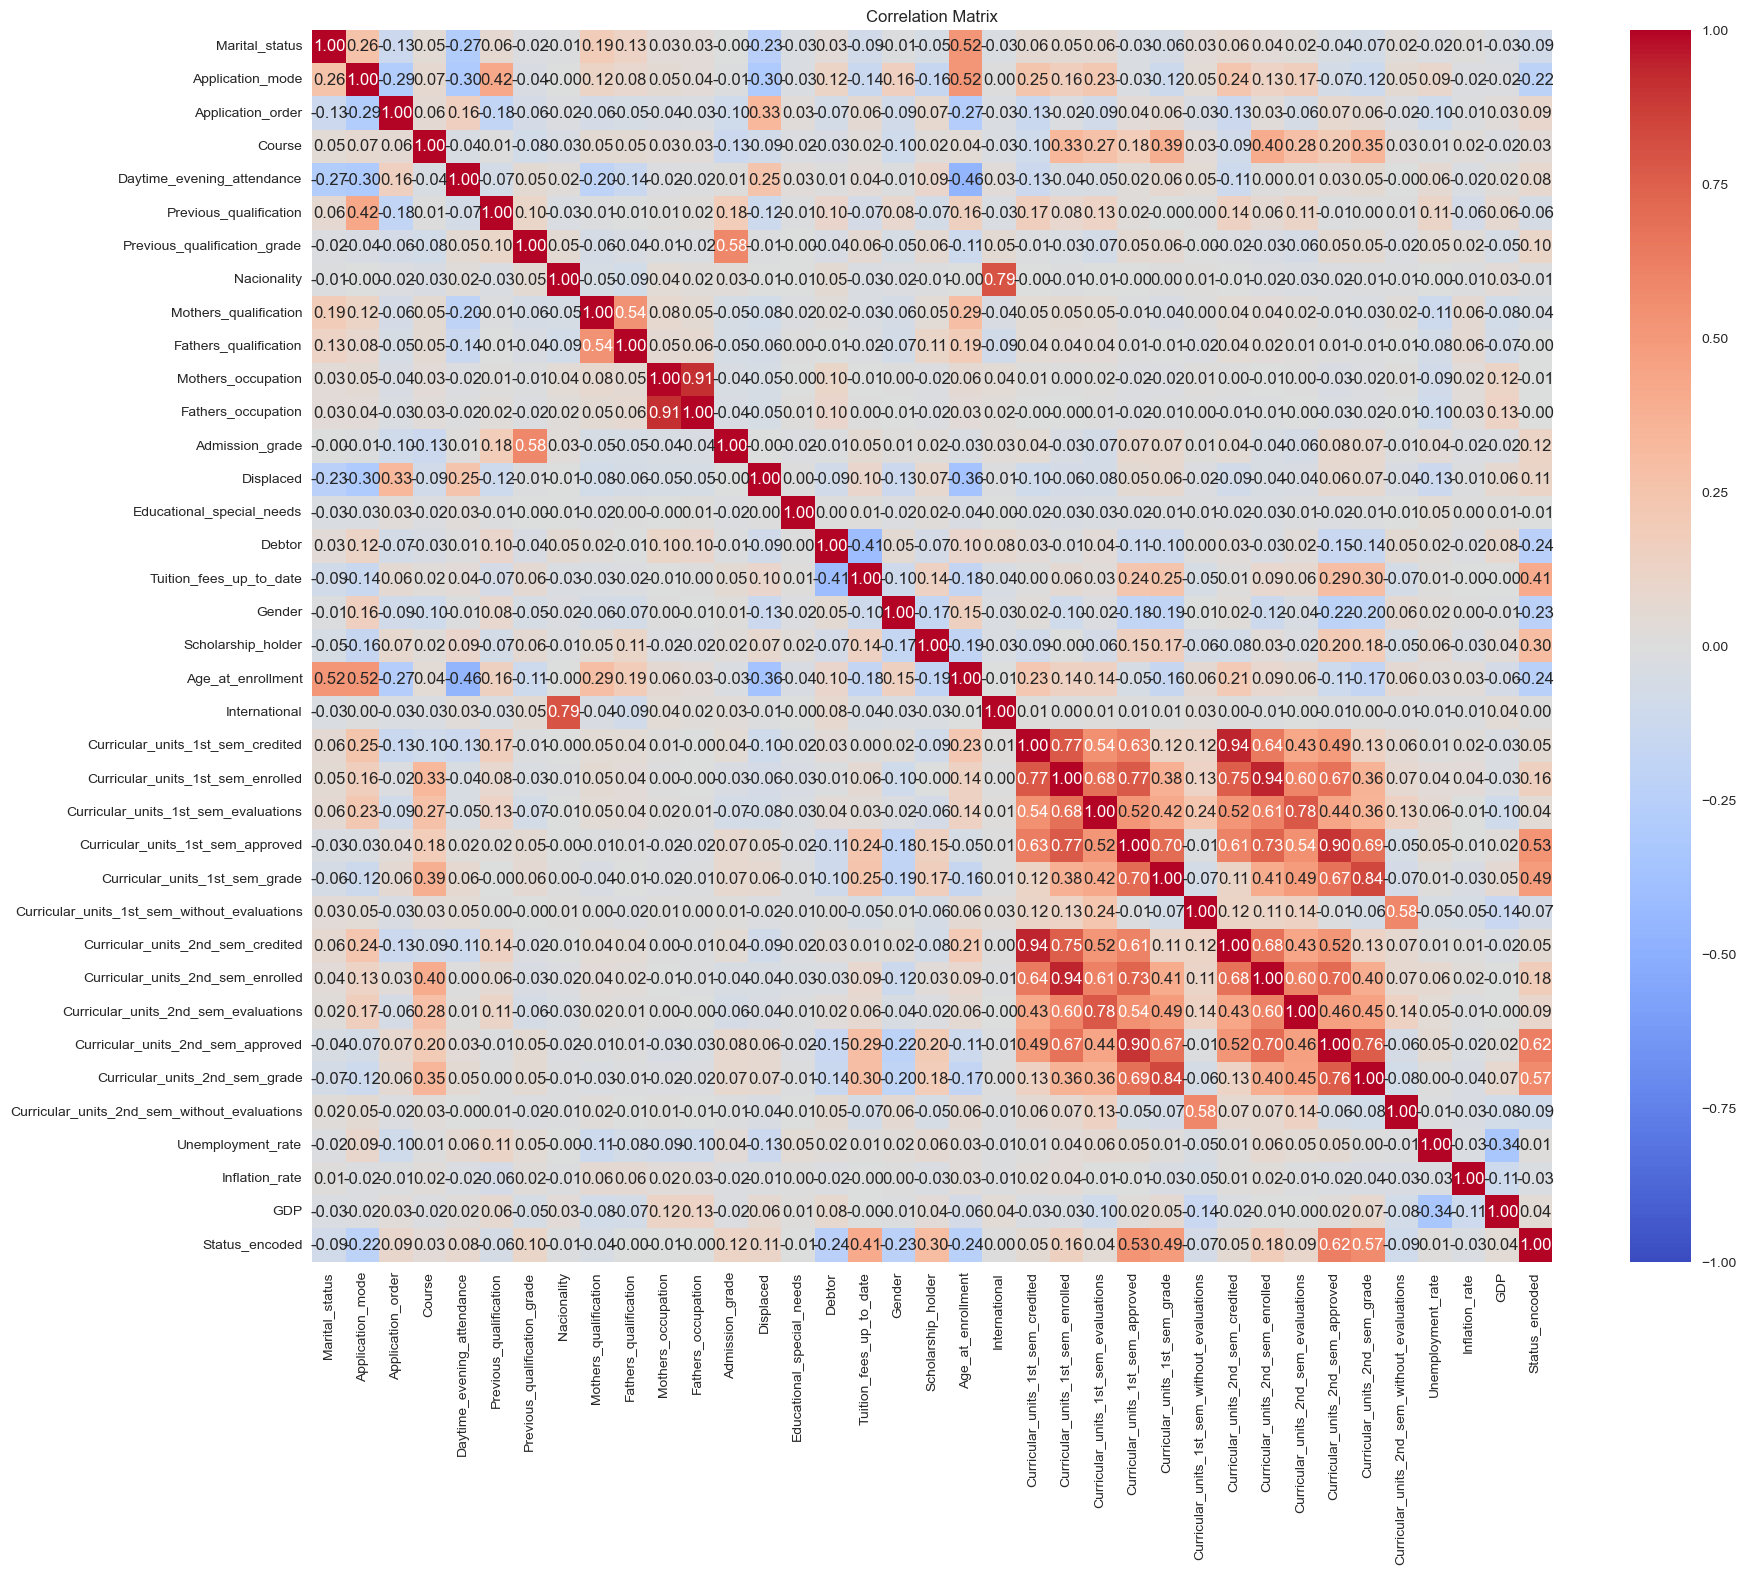

In [18]:
plt.figure(figsize=(20, 16)) 
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix')

In [21]:
corr = df.corr(numeric_only=True)

corr_target = corr['Status_encoded'].sort_values(ascending=False)

corr_target

Status_encoded                                  1.000000
Curricular_units_2nd_sem_approved               0.624157
Curricular_units_2nd_sem_grade                  0.566827
Curricular_units_1st_sem_approved               0.529123
Curricular_units_1st_sem_grade                  0.485207
Tuition_fees_up_to_date                         0.409827
Scholarship_holder                              0.297595
Curricular_units_2nd_sem_enrolled               0.175847
Curricular_units_1st_sem_enrolled               0.155974
Admission_grade                                 0.120889
Displaced                                       0.113986
Previous_qualification_grade                    0.103764
Curricular_units_2nd_sem_evaluations            0.092721
Application_order                               0.089791
Daytime_evening_attendance                      0.075107
Curricular_units_2nd_sem_credited               0.054004
Curricular_units_1st_sem_credited               0.048150
Curricular_units_1st_sem_evalua

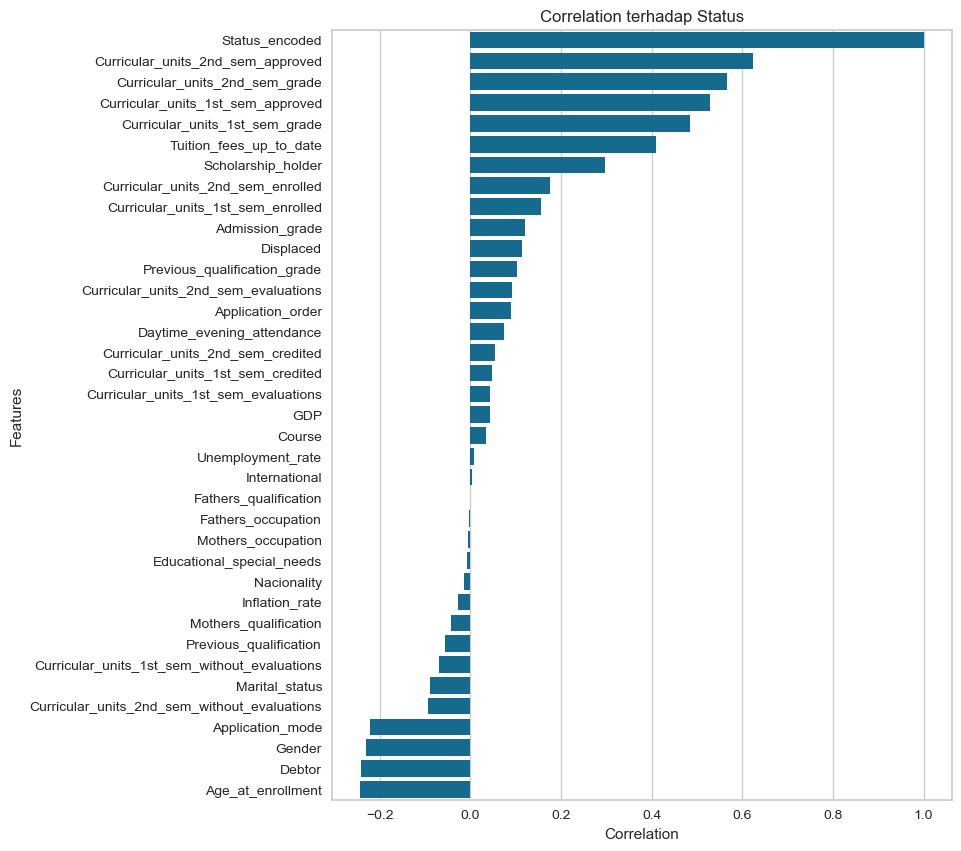

In [26]:
import seaborn as sns

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)

plt.title('Correlation terhadap Status')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.show()

## Modeling

## Evaluation